In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)
Y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)
class ExtensionMLP:
    def __init__(
        self,
        input_size=2,
        hidden_size=2,
        output_size=1,
        learning_rate=1.0,
        activation="sigmoid",
        loss_function="mse",
        seed=42
    ):
        self.learning_rate = learning_rate
        self.activation_name = activation
        self.loss_function = loss_function
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(
            0,
            0.5,
            (input_size, hidden_size)
        )
        self.b1 = np.zeros(
            (1, hidden_size)
        )
        self.W2 = rng.normal(
            0,
            0.5,
            (hidden_size, output_size)
        )
        self.b2 = np.zeros(
            (1, output_size)
        )
    # Sigmoid
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    # Hidden activation
    def activation(self, z):
        if self.activation_ame == "sigmoid":
            return self.sigmoid(z)
        elif self.activation_name == "tanh":
            return np.tanh(z)
    # Activation derivative
    def activation_derivative(self, z, a):
        if self.activation_name == "sigmoid":
            return a * (1 - a)
        elif self.activation_name == "tanh":
            return 1 - a ** 2
    # Forward propagation
    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.activation(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        # Output uses sigmoid
        self.Y_hat = self.sigmoid(self.Z2)
        return self.Y_hat
    # Loss
    def calculate_loss(self, Y, Y_hat):
        if self.loss_function == "mse":
            return np.mean(
                (Y - Y_hat) ** 2
            )
        elif self.loss_function == "bce":
            eps = 1e-12
            Y_hat = np.clip(
                Y_hat,
                eps,
                1 - eps
            )
            return -np.mean(
                Y * np.log(Y_hat)
                +
                (1 - Y) *
                np.log(1 - Y_hat)
            )
    # Training
    def train(self, X, Y, epochs=10000):
        loss_history = []
        n = X.shape[0]
        for epoch in range(epochs):
            # Forward
            Y_hat = self.forward(X)
            # Loss
            loss = self.calculate_loss(
                Y,
                Y_hat
            )
            loss_history.append(loss)
            # Output delta
            if self.loss_function == "mse":
                delta2 = (
                    (Y_hat - Y)
                    * Y_hat
                    * (1 - Y_hat)
                )
            elif self.loss_function == "bce":
                delta2 = Y_hat - Y
            # Output gradients
            dW2 = (
                self.A1.T @ delta2
            ) / n
            db2 = (
                np.sum(
                    delta2,
                    axis=0,
                    keepdims=True
                ) / n
            )
            # Hidden delta
            delta1 = (
                delta2 @ self.W2.T
            ) * self.activation_derivative(
                self.Z1,
                self.A1
            )
            # Hidden gradients
            dW1 = (
                X.T @ delta1
            ) / n
            db1 = (
                np.sum(
                    delta1,
                    axis=0,
                    keepdims=True
                ) / n
            )
            # Parameter updates
            self.W2 -= (
                self.learning_rate * dW2
            )
            self.b2 -= (
                self.learning_rate * db2
            )
            self.W1 -= (
                self.learning_rate * dW1
            )
            self.b1 -= (
                self.learning_rate * db1
            )
        return loss_history
    # Prediction
    def predict_probability(self, X):
        return self.forward(X)
    def predict(self, X):

        return (
            self.predict_probability(X) >= 0.5
        ).astype(int)

Final Tanh MSE: 0.0001715167074643115

Predictions:
[0. 0.] Actual: 0 Probability: 0.0115 Prediction: 0
[0. 1.] Actual: 1 Probability: 0.985 Prediction: 1
[1. 0.] Actual: 1 Probability: 0.9851 Prediction: 1
[1. 1.] Actual: 0 Probability: 0.0103 Prediction: 0


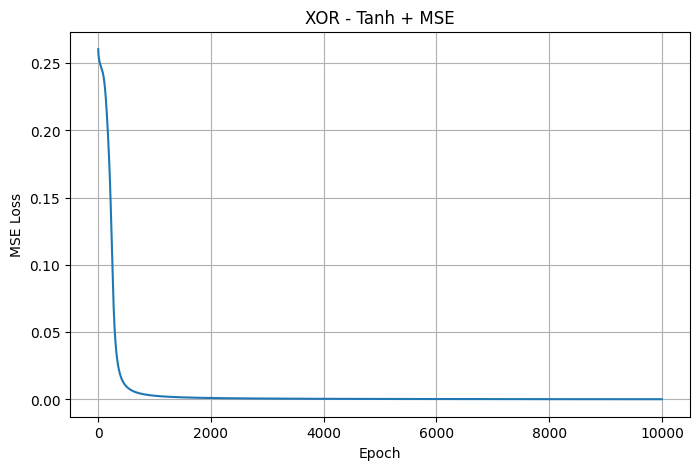

In [ ]:
tanh_model = ExtensionMLP(
    input_size=2,
    hidden_size=2,
    output_size=1,
    learning_rate=1.0,
    activation="tanh",
    loss_function="mse",
    seed=42
)
tanh_loss = tanh_model.train(
    X,
    Y,
    epochs=10000
)
print("Final Tanh MSE:", tanh_loss[-1])
probabilities = tanh_model.predict_probability(X)
predictions = tanh_model.predict(X)
print("\nPredictions:")
for i in range(len(X)):
    print(
        X[i],
        "Actual:",
        int(Y[i][0]),
        "Probability:",
        round(float(probabilities[i][0]), 4),
        "Prediction:",
        int(predictions[i][0])
    )
plt.figure(figsize=(8, 5))
plt.plot(tanh_loss)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("XOR - Tanh + MSE")
plt.grid(True)
plt.show()

Final BCE: 0.0019125291553701478

Predictions:
[0. 0.] Actual: 0 Probability: 0.0017 Prediction: 0
[0. 1.] Actual: 1 Probability: 0.9978 Prediction: 1
[1. 0.] Actual: 1 Probability: 0.9978 Prediction: 1
[1. 1.] Actual: 0 Probability: 0.0015 Prediction: 0


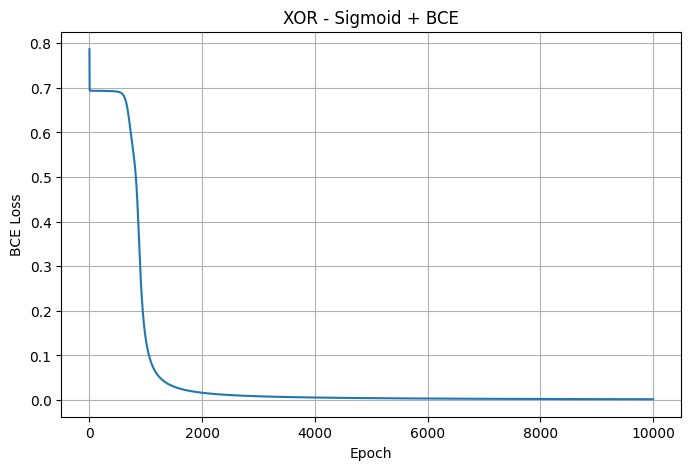

In [ ]:
bce_model = ExtensionMLP(
    input_size=2,
    hidden_size=2,
    output_size=1,
    learning_rate=1.0,
    activation="sigmoid",
    loss_function="bce",
    seed=42
)
bce_loss = bce_model.train(
    X,
    Y,
    epochs=10000
)
print("Final BCE:", bce_loss[-1])
probabilities = bce_model.predict_probability(X)
predictions = bce_model.predict(X)
print("\nPredictions:")
for i in range(len(X)):
    print(
        X[i],
        "Actual:",
        int(Y[i][0]),
        "Probability:",
        round(float(probabilities[i][0]), 4),
        "Prediction:",
        int(predictions[i][0])
    )
plt.figure(figsize=(8, 5))
plt.plot(bce_loss)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("XOR - Sigmoid + BCE")
plt.grid(True)
plt.show()

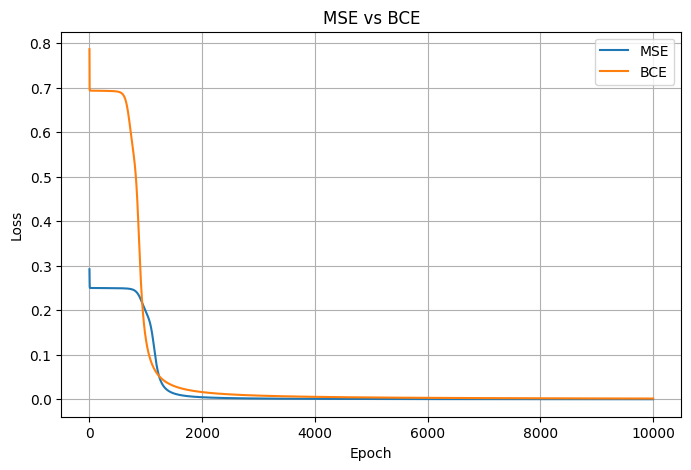

In [ ]:
# MSE model
mse_model = ExtensionMLP(
    hidden_size=2,
    learning_rate=3.0,
    activation="sigmoid",
    loss_function="mse",
    seed=42
)
mse_loss = mse_model.train(
    X,
    Y,
    epochs=10000
)
# Compare
plt.figure(figsize=(8, 5))
plt.plot(
    mse_loss,
    label="MSE"
)
plt.plot(
    bce_loss,
    label="BCE"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MSE vs BCE")
plt.legend()
plt.grid(True)
plt.show()

Hidden Units: 2 | Final BCE: 0.001913
Hidden Units: 5 | Final BCE: 0.000489
Hidden Units: 10 | Final BCE: 0.000459


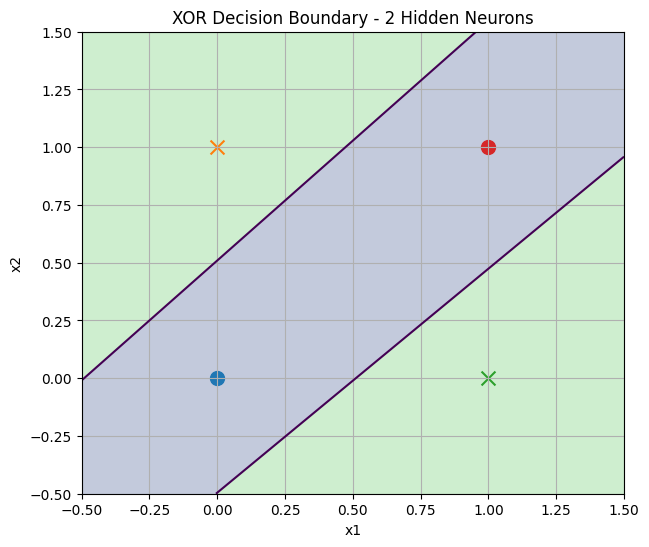

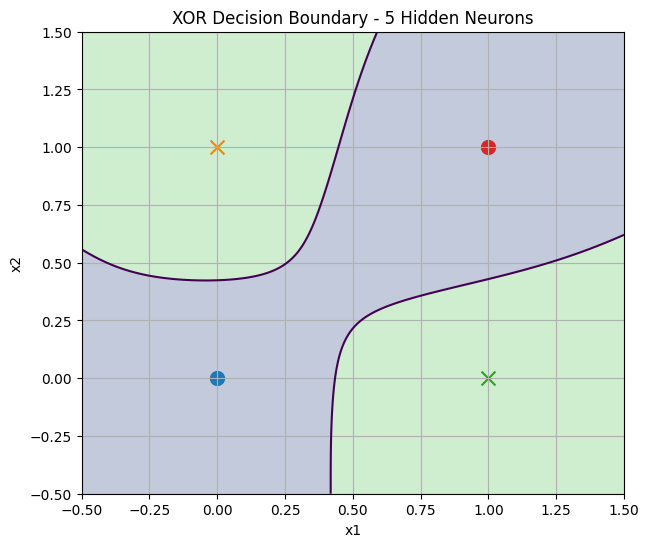

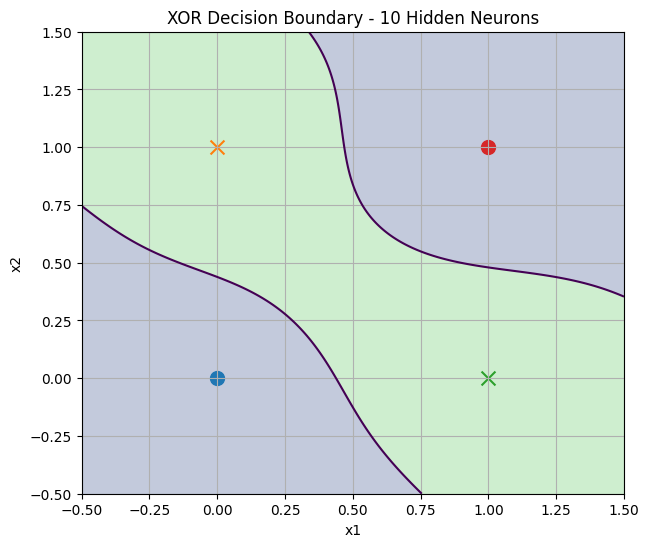


========== 2 HIDDEN NEURONS ==========
[0. 0.] Actual: 0 Probability: 0.0017 Prediction: 0
[0. 1.] Actual: 1 Probability: 0.9978 Prediction: 1
[1. 0.] Actual: 1 Probability: 0.9978 Prediction: 1
[1. 1.] Actual: 0 Probability: 0.0015 Prediction: 0

========== 5 HIDDEN NEURONS ==========
[0. 0.] Actual: 0 Probability: 0.0003 Prediction: 0
[0. 1.] Actual: 1 Probability: 0.9995 Prediction: 1
[1. 0.] Actual: 1 Probability: 0.9996 Prediction: 1
[1. 1.] Actual: 0 Probability: 0.0007 Prediction: 0

========== 10 HIDDEN NEURONS ==========
[0. 0.] Actual: 0 Probability: 0.0005 Prediction: 0
[0. 1.] Actual: 1 Probability: 0.9996 Prediction: 1
[1. 0.] Actual: 1 Probability: 0.9995 Prediction: 1
[1. 1.] Actual: 0 Probability: 0.0005 Prediction: 0


In [ ]:
hidden_units = [2, 5, 10]
models = {}
for h in hidden_units:
    model = ExtensionMLP(
        input_size=2,
        hidden_size=h,
        output_size=1,
        learning_rate=1.0,
        activation="sigmoid",
        loss_function="bce",
        seed=42
    )
    history = model.train(
        X,
        Y,
        epochs=10000
    )
    models[h] = model
    print(
        "Hidden Units:",
        h,
        "| Final BCE:",
        round(history[-1], 6)
    )
# Decision boundary function
def plot_decision_boundary(model, title):
    xx, yy = np.meshgrid(
        np.linspace(-0.5, 1.5, 300),
        np.linspace(-0.5, 1.5, 300)
    )
    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]
    probabilities = model.predict_probability(grid)
    Z = probabilities.reshape(
        xx.shape
    )
    plt.figure(figsize=(7, 6))
    plt.contourf(
        xx,
        yy,
        Z,
        levels=[0, 0.5, 1],
        alpha=0.3
    )
    plt.contour(
        xx,
        yy,
        Z,
        levels=[0.5]
    )
    # Plot XOR samples
    for i in range(len(X)):
        if Y[i][0] == 0:
            plt.scatter(
                X[i][0],
                X[i][1],
                marker="o",
                s=100
            )
        else:
            plt.scatter(
                X[i][0],
                X[i][1],
                marker="x",
                s=100
            )
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.show()
# Plot boundaries
for h in hidden_units:
    plot_decision_boundary(
        models[h],
        f"XOR Decision Boundary - {h} Hidden Neurons"
    )
# Predictions
for h in hidden_units:
    print(
        "\n==========",
        h,
        "HIDDEN NEURONS =========="
    )
    probabilities = (
        models[h].predict_probability(X)
    )
    predictions = (
        models[h].predict(X)
    )
    for i in range(len(X)):
        print(
            X[i],
            "Actual:",
            int(Y[i][0]),
            "Probability:",
            round(
                float(probabilities[i][0]),
                4
            ),
            "Prediction:",
            int(predictions[i][0])
        )